## Классификация

In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt


dish_data = pd.read_csv("./data/dish_data.csv", index_col="id")
dish_data.describe()

,total_appeared,life_time,price_range,cluster
count,36150.000000,36150.000000,36150.000000,36150.000000
mean,3.841372,2.533089,0.649935,0.558783
std,2.274808,1.276301,1.036070,0.496539
min,0.693147,0.693147,0.000000,0.000000
25%,2.302585,1.386294,0.048790,0.000000
50%,3.258097,2.639057,0.223144,1.000000
75%,4.976734,3.610918,0.717840,1.000000
max,16.806009,7.606885,8.023077,1.000000


In [100]:
dish_data["cluster"].value_counts()

cluster
1    20200
0    15950
Name: count, dtype: int64

Получаем, что классы сопоставимы. Следовательно, для определения результатов классификации будем использовать  `accuracy`

In [101]:
y = dish_data["cluster"]
X = dish_data.drop(columns="cluster")

Сплитуем данные

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<Axes: >

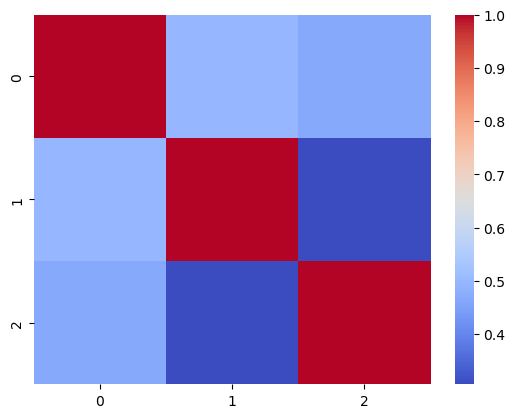

In [103]:
sns.heatmap(pd.DataFrame(X_train).corr(), cmap="coolwarm")

### Наивный Байес

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_predicts = nb_model.predict(X_test)
print(accuracy_score(y_test, nb_predicts))

0.9498782916574463


In [105]:
train_acc = nb_model.score(X_train, y_train)
test_acc = nb_model.score(X_test, y_test)

print(train_acc, test_acc)

0.9509811153732665 0.9498782916574463


In [106]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

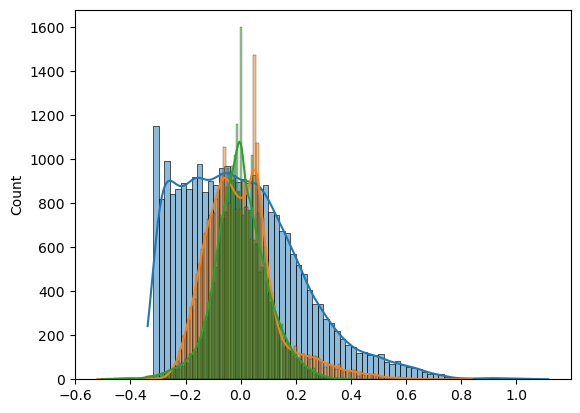

In [107]:
import seaborn as sns

for i in range(3):
    sns.histplot(X_train_pca[:, i], kde=True)

<Axes: >

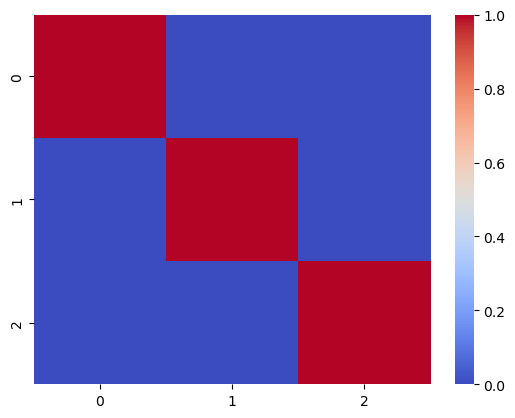

In [108]:
sns.heatmap(pd.DataFrame(X_train_pca).corr(), cmap="coolwarm")

In [109]:
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_pca, y_train)

nb_predicts = nb_model.predict(X_test_pca)
print(accuracy_score(y_test, nb_predicts))

0.9633768532861252


In [110]:
train_acc = nb_model.score(X_train_pca, y_train)
test_acc = nb_model.score(X_test_pca, y_test)

print(train_acc, test_acc)

0.9637061079964592 0.9633768532861252


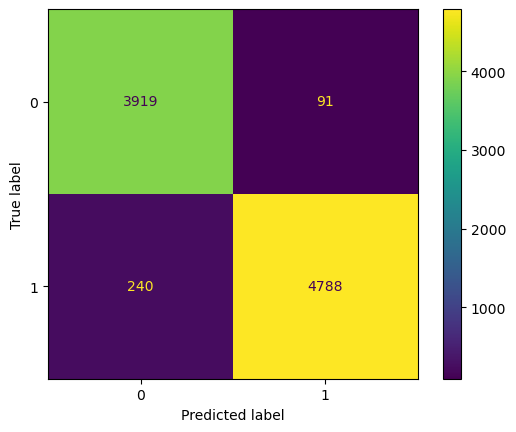

In [111]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(nb_model, X_test_pca, y_test)
plt.show()

### Дерево решений

In [112]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
tree_model.fit(X_train, y_train)

print(tree_model.get_depth())
print(tree_model.get_n_leaves())

tree_predicts = tree_model.predict(X_test)
print(accuracy_score(y_test, tree_predicts))

5
29
0.9795308696614295


In [113]:
train_acc = tree_model.score(X_train, y_train)
test_acc = tree_model.score(X_test, y_test)

print(train_acc, test_acc)

0.9815948657421069 0.9795308696614295


In [114]:
tree_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
tree_model.fit(X_train_pca, y_train)

print(tree_model.get_depth())
print(tree_model.get_n_leaves())

tree_predicts = tree_model.predict(X_test_pca)
print(accuracy_score(y_test, tree_predicts))

5
24
0.9962381057756141


In [115]:
train_acc = tree_model.score(X_train_pca, y_train)
test_acc = tree_model.score(X_test_pca, y_test)

print(train_acc, test_acc)

0.9967173207435822 0.9962381057756141


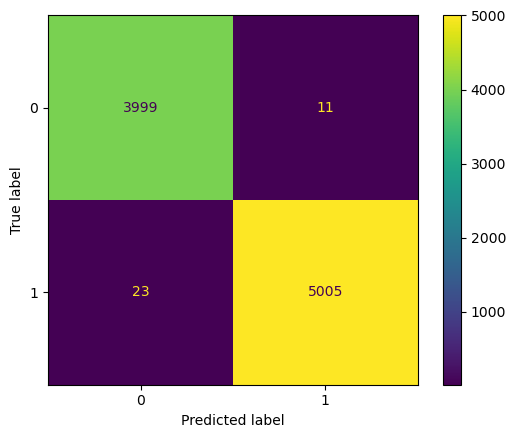

In [116]:
ConfusionMatrixDisplay.from_estimator(tree_model, X_test_pca, y_test)
plt.show()

[Text(0.4289772727272727, 0.9166666666666666, 'x[0] <= 0.007\ngini = 0.493\nsamples = 27112\nvalue = [11940, 15172]'),
 Text(0.125, 0.75, 'x[1] <= -0.18\ngini = 0.023\nsamples = 14991\nvalue = [178, 14813]'),
 Text(0.27698863636363635, 0.8333333333333333, 'True  '),
 Text(0.045454545454545456, 0.5833333333333334, 'x[1] <= -0.192\ngini = 0.146\nsamples = 63\nvalue = [58, 5]'),
 Text(0.022727272727272728, 0.4166666666666667, 'gini = 0.375\nsamples = 20\nvalue = [15, 5]'),
 Text(0.06818181818181818, 0.4166666666666667, 'gini = 0.0\nsamples = 43\nvalue = [43, 0]'),
 Text(0.20454545454545456, 0.5833333333333334, 'x[0] <= 0.001\ngini = 0.016\nsamples = 14928\nvalue = [120.0, 14808.0]'),
 Text(0.11363636363636363, 0.4166666666666667, 'x[0] <= -0.005\ngini = 0.005\nsamples = 14667\nvalue = [36, 14631]'),
 Text(0.06818181818181818, 0.25, 'x[1] <= -0.166\ngini = 0.001\nsamples = 14384\nvalue = [5, 14379]'),
 Text(0.045454545454545456, 0.08333333333333333, 'gini = 0.1\nsamples = 95\nvalue = [5, 9

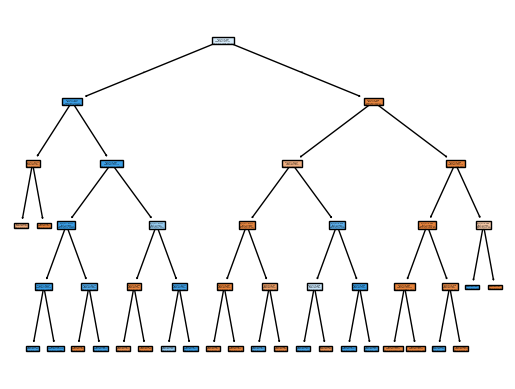

In [117]:
from sklearn.tree import plot_tree
plot_tree(tree_model, max_depth=5, filled=True)

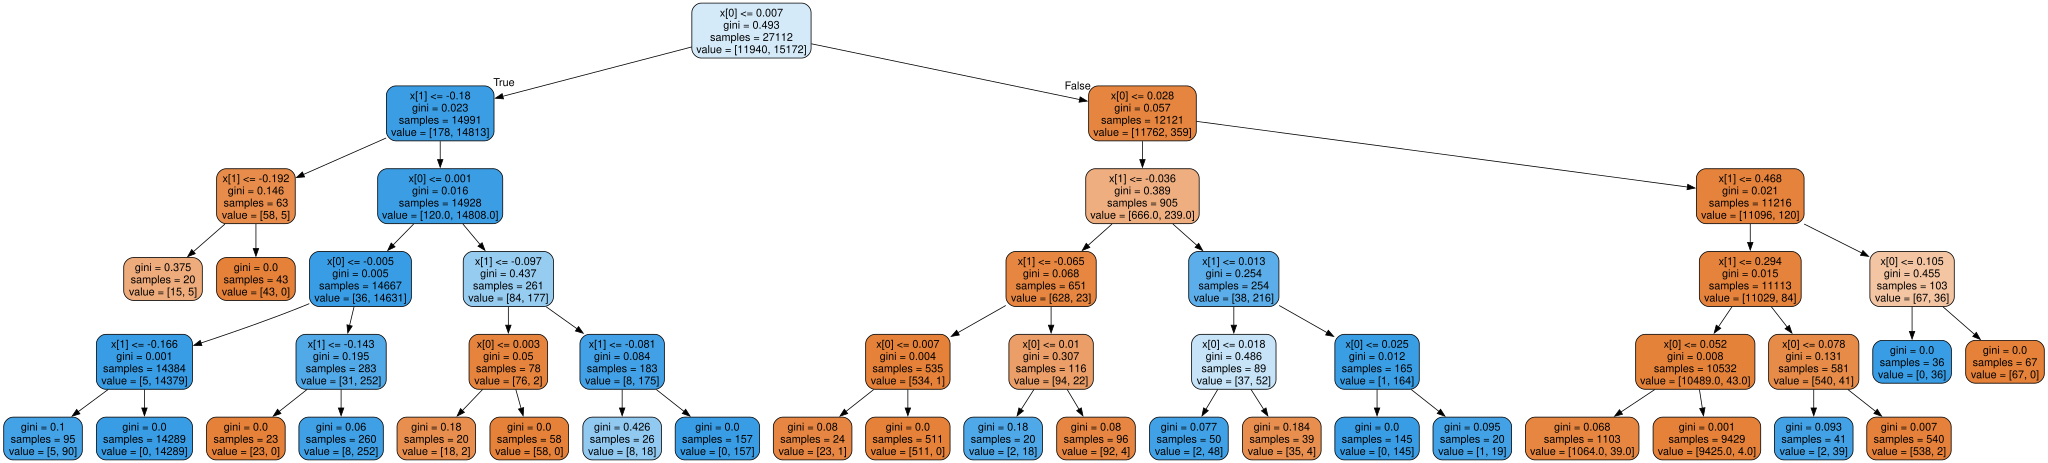

In [118]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    tree_model,
    out_file=None,
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)
graph

### Random forest

In [119]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=42)
forest_model.fit(X_train, y_train)

forest_predicts = forest_model.predict(X_test)
print(accuracy_score(y_test, forest_predicts))

0.9972339013055986


In [120]:
train_acc = forest_model.score(X_train, y_train)
test_acc = forest_model.score(X_test, y_test)

print(train_acc, test_acc)

0.9987828267925641 0.9972339013055986


In [121]:
forest_model = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=42)
forest_model.fit(X_train_pca, y_train)

forest_predicts = forest_model.predict(X_test_pca)
print(accuracy_score(y_test, forest_predicts))

0.9988935605222394


In [122]:
train_acc =forest_model.score(X_train_pca, y_train)
test_acc = forest_model.score(X_test_pca, y_test)

print(train_acc, test_acc)

0.9996680436706993 0.9988935605222394


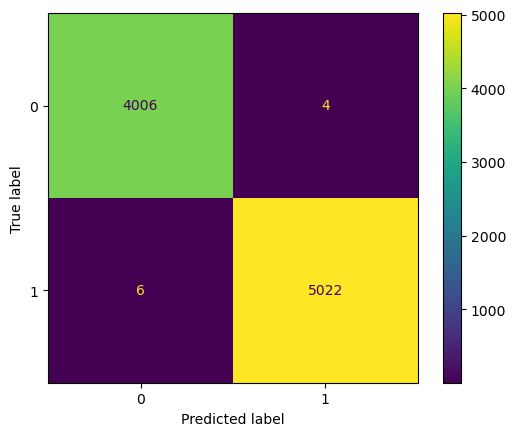

In [123]:
ConfusionMatrixDisplay.from_estimator(forest_model, X_test_pca, y_test)
plt.show()